# Análise de Infrações PF x PJ

In [22]:
import pandas as pd # Importar dados
import numpy as np # Importar Matemática
import matplotlib.pyplot as plt # Importar gráficos

df = pd.read_csv('2.4-infracoes-por-pessoa-24.csv', sep=';') # Carregar o arquivo dos dados a serem analisados
df = df.dropna(axis=1, how='all') # Remover colunas vazias
print(df.head()) # Visualizar as primeiras linhas


   ANOMES                                 DESC_INF     DESCR_MUNIC_INF  \
0  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC  ARMACAO DOS BUZIOS   
1  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC  ARMACAO DOS BUZIOS   
2  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC       IGUABA GRANDE   
3  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC       IGUABA GRANDE   
4  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC              MACUCO   

      LIT_PTO      TIPO    PF   PJ  AIT  
0  GRAVISSIMA    MANUAL   5.0  NaN    5  
1  GRAVISSIMA  PALM TOP  45.0  1.0   46  
2  GRAVISSIMA    MANUAL   7.0  NaN    7  
3  GRAVISSIMA  PALM TOP  19.0  NaN   19  
4  GRAVISSIMA    MANUAL   1.0  NaN    1  


In [23]:
total_pf = df['PF'].sum() # Calcular total de infrações Pessoa Física
total_pj = df['PJ'].sum() # Calcular total de infraçoes Pessoa Jurídica
print(f'Total infrações pessoa Física: {total_pf} // Total infrações Pessoa Jurídica: {total_pj}') # Exibir resuldados


Total infrações pessoa Física: 5398223.0 // Total infrações Pessoa Jurídica: 1214705.0


In [24]:
df.groupby('DESCR_MUNIC_INF')[['PF','PJ']].sum().sort_values('PF', ascending=False).head()


,PF,PJ
DESCR_MUNIC_INF,,
RIO DE JANEIRO,2140247.0,634846.0
ITAGUAI,534389.0,65917.0
NITEROI,227866.0,68564.0
MACAE,168099.0,32420.0
CABO FRIO,156604.0,26087.0


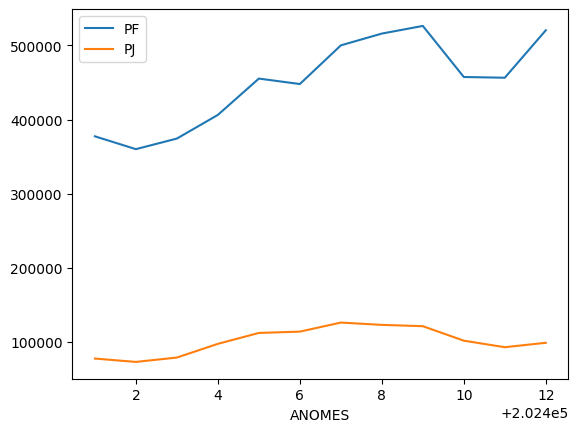

In [25]:
df.groupby('ANOMES')[['PF','PJ']].sum().plot()
plt.show()


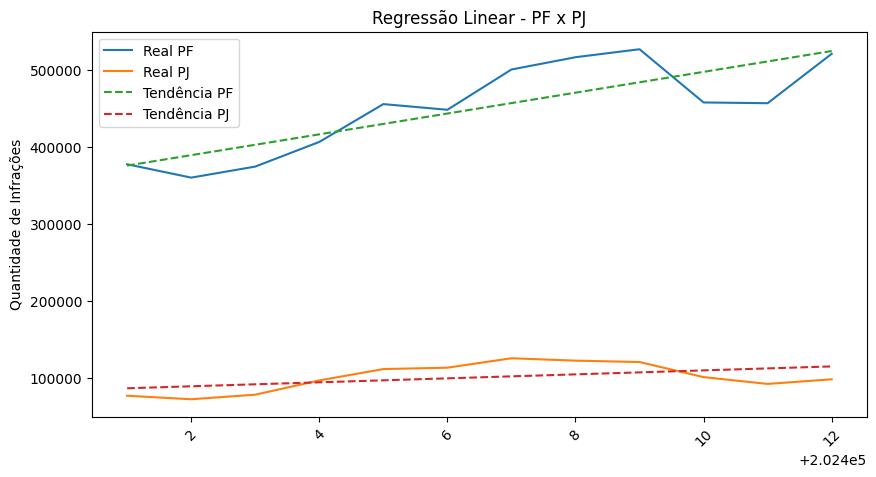

In [27]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# agrupar dados no tempo
tempo = df.groupby('ANOMES')[['PF','PJ']].sum()

# resetar índice
tempo = tempo.reset_index()

# criar variável numérica (tempo)
tempo['ANOMES_NUM'] = range(len(tempo))

# ======================
# REGRESSÃO PF
# ======================
X = tempo[['ANOMES_NUM']]
y_pf = tempo['PF']

modelo_pf = LinearRegression()
modelo_pf.fit(X, y_pf)

tempo['Tendencia_PF'] = modelo_pf.predict(X)

# ======================
# REGRESSÃO PJ
# ======================
y_pj = tempo['PJ']

modelo_pj = LinearRegression()
modelo_pj.fit(X, y_pj)

tempo['Tendencia_PJ'] = modelo_pj.predict(X)

# ======================
# GRÁFICO COMPLETO
# ======================

plt.figure(figsize=(10,5))

# dados reais
plt.plot(tempo['ANOMES'], tempo['PF'], label='Real PF')
plt.plot(tempo['ANOMES'], tempo['PJ'], label='Real PJ')

# tendências (tracejadas)
plt.plot(tempo['ANOMES'], tempo['Tendencia_PF'], linestyle='--', label='Tendência PF')
plt.plot(tempo['ANOMES'], tempo['Tendencia_PJ'], linestyle='--', label='Tendência PJ')

plt.xticks(rotation=45)
plt.legend()
plt.title('Regressão Linear - PF x PJ')
plt.ylabel('Quantidade de Infrações')
plt.show()